### Load Data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

blue_players = np.load(PROCESSED_DIR / "blue_players.npy")
red_players  = np.load(PROCESSED_DIR / "red_players.npy")
blue_champs  = np.load(PROCESSED_DIR / "blue_champs.npy")
red_champs   = np.load(PROCESSED_DIR / "red_champs.npy")
league_ids   = np.load(PROCESSED_DIR / "league_ids.npy")
y            = np.load(PROCESSED_DIR / "y.npy")

### Inspect Data

In [2]:
league_lookup = pd.read_csv(PROCESSED_DIR / "league_lookup.csv")

print("Blue players shape:", blue_players.shape)
print("Red players shape:", red_players.shape)
print("Blue champs shape:", blue_champs.shape)
print("Red champs shape:", red_champs.shape)
print("League ids shape:", league_ids.shape)
print("y shape:", y.shape)

print(f"\nTotal matches: {len(y)}")
print(f"Blue winrate: {y.mean():.3f}")
print(f"Max player id: {max(blue_players.max(), red_players.max())}")
print(f"Max champ id: {max(blue_champs.max(), red_champs.max())}")

print("\nMatches per league:")
for _, row in league_lookup.iterrows():
    count = (league_ids == row["league_id"]).sum()
    print(f"  {row['league_name']}: {count}")

Blue players shape: (1959, 5)
Red players shape: (1959, 5)
Blue champs shape: (1959, 5)
Red champs shape: (1959, 5)
League ids shape: (1959,)
y shape: (1959,)

Total matches: 1959
Blue winrate: 0.523
Max player id: 315
Max champ id: 152

Matches per league:
  LCK: 555
  LEC: 306
  LPL: 805
  PCS: 293


### Volume checks

In [3]:
N_players = int(max(blue_players.max(), red_players.max()) + 1)
N_champs  = int(max(blue_champs.max(), red_champs.max()) + 1)
N_leagues = int(league_ids.max() + 1)
N_matches = len(y)

all_players = np.concatenate([blue_players.flatten(), red_players.flatten()])
all_champs  = np.concatenate([blue_champs.flatten(), red_champs.flatten()])

player_game_counts = np.bincount(all_players.astype(int), minlength=N_players)
champ_game_counts  = np.bincount(all_champs.astype(int),  minlength=N_champs)

print(f"Players: {N_players}")
print(f"Champions: {N_champs}")
print(f"Leagues: {N_leagues}")
print(f"Matches: {N_matches}")

print(f"\n--- Player frequency ---")
print(f"Median games/player: {np.median(player_game_counts):.0f}")
print(f"Min games/player:    {player_game_counts.min()}")
print(f"Players with <10 games: {(player_game_counts < 10).sum()}")
print(f"Players with <5 games:  {(player_game_counts < 5).sum()}")

print(f"\n--- Champion frequency ---")
print(f"Median games/champ:  {np.median(champ_game_counts):.0f}")
print(f"Min games/champ:     {champ_game_counts.min()}")
print(f"Champs with <5 games:  {(champ_game_counts < 5).sum()}")
print(f"Champs with <10 games: {(champ_game_counts < 10).sum()}")

Players: 316
Champions: 153
Leagues: 4
Matches: 1959

--- Player frequency ---
Median games/player: 58
Min games/player:    0
Players with <10 games: 47
Players with <5 games:  25

--- Champion frequency ---
Median games/champ:  46
Min games/champ:     1
Champs with <5 games:  25
Champs with <10 games: 41


### Prior Predictive Simulation

σ=0.1: 0.0% of games have >95% or <5% win prob
σ=0.3: 0.2% of games have >95% or <5% win prob
σ=0.5: 6.4% of games have >95% or <5% win prob
σ=1.0: 34.4% of games have >95% or <5% win prob


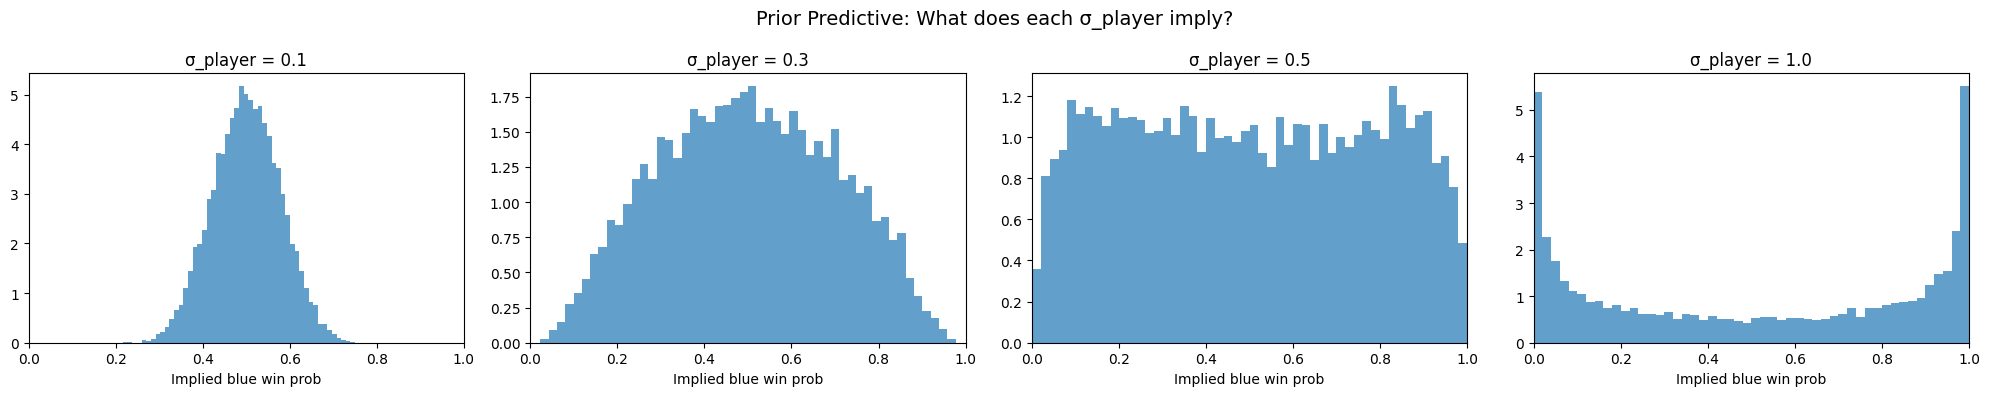

In [4]:
sigma_candidates = [0.1, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(1, len(sigma_candidates), figsize=(20, 4))

for ax, sigma_val in zip(axes, sigma_candidates):
    player_effects = np.random.normal(0, sigma_val, size=(10000, 10))
    net_advantage = player_effects[:, :5].sum(axis=1) - player_effects[:, 5:].sum(axis=1)
    win_prob = 1 / (1 + np.exp(-net_advantage))

    ax.hist(win_prob, bins=50, density=True, alpha=0.7)
    ax.set_title(f"σ_player = {sigma_val}")
    ax.set_xlabel("Implied blue win prob")
    ax.set_xlim(0, 1)

    extreme = ((win_prob < 0.05) | (win_prob > 0.95)).mean()
    print(f"σ={sigma_val}: {extreme:.1%} of games have >95% or <5% win prob")

plt.suptitle("Prior Predictive: What does each σ_player imply?", fontsize=14)
plt.tight_layout()
plt.show()

### PyMC Prior Predictive Check

c:\Users\OMEN\Desktop\BayesianLeague\.venv\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Sampling: [alpha, beta_blue, mu_blue, phi, sigma_blue, sigma_champ, sigma_player, y_obs]


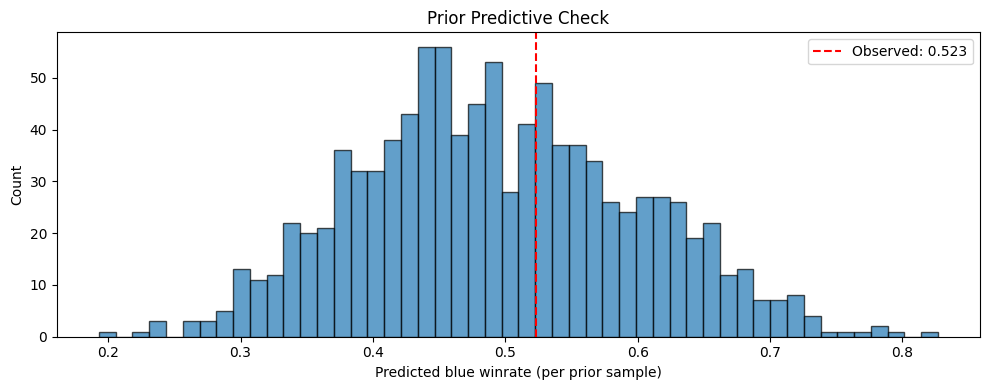

Prior predictive mean winrate: 0.493


In [5]:
import pymc as pm
import arviz as az

with pm.Model() as prior_check_model:
    sigma_player = pm.HalfNormal("sigma_player", sigma=0.3)
    sigma_champ  = pm.HalfNormal("sigma_champ",  sigma=0.2)

    phi   = pm.Normal("phi",   mu=0.0, sigma=sigma_player, shape=N_players)
    alpha = pm.Normal("alpha", mu=0.0, sigma=sigma_champ,  shape=N_champs)

    mu_blue    = pm.Normal("mu_blue", mu=0.0, sigma=0.5)
    sigma_blue = pm.HalfNormal("sigma_blue", sigma=0.2)
    beta_blue  = pm.Normal("beta_blue", mu=mu_blue, sigma=sigma_blue, shape=N_leagues)

    player_adv = phi[blue_players].sum(axis=1) - phi[red_players].sum(axis=1)
    champ_adv  = alpha[blue_champs].sum(axis=1) - alpha[red_champs].sum(axis=1)

    eta = beta_blue[league_ids] + player_adv + champ_adv
    p   = pm.math.sigmoid(eta)
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    prior_pred = pm.sample_prior_predictive(samples=1000, random_seed=42)

prior_winrates = prior_pred.prior_predictive["y_obs"].mean(dim="y_obs_dim_0").values.flatten()

plt.figure(figsize=(10, 4))
plt.hist(prior_winrates, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(x=y.mean(), color='red', linestyle='--', label=f"Observed: {y.mean():.3f}")
plt.xlabel("Predicted blue winrate (per prior sample)")
plt.ylabel("Count")
plt.title("Prior Predictive Check")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Prior predictive mean winrate: {prior_winrates.mean():.3f}")

### Compare Prior Configurations

In [ ]:
results = {}

prior_configs = {
    "tight":    {"sp": 0.1, "sc": 0.1, "sb": 0.3},
    "medium":   {"sp": 0.3, "sc": 0.2, "sb": 0.5},
    "wide":     {"sp": 0.5, "sc": 0.3, "sb": 1.0},
    "data_led": {"sp": 0.4, "sc": 0.2, "sb": 0.5},
}

for name, cfg in prior_configs.items():
    print(f"\n--- Fitting: {name} (σ_p={cfg['sp']}, σ_c={cfg['sc']}, σ_b={cfg['sb']}) ---")

    with pm.Model() as m:
        sigma_player = pm.HalfNormal("sigma_player", sigma=cfg["sp"])
        sigma_champ  = pm.HalfNormal("sigma_champ",  sigma=cfg["sc"])

        phi_raw   = pm.Normal("phi_raw",   mu=0.0, sigma=1.0, shape=N_players)
        alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, shape=N_champs)

        phi   = pm.Deterministic("phi",   phi_raw * sigma_player)
        alpha = pm.Deterministic("alpha", alpha_raw * sigma_champ)

        mu_blue    = pm.Normal("mu_blue", mu=0.0, sigma=cfg["sb"])
        sigma_blue = pm.HalfNormal("sigma_blue", sigma=0.2)

        beta_blue_raw = pm.Normal("beta_blue_raw", mu=0.0, sigma=1.0, shape=N_leagues)
        beta_blue = pm.Deterministic("beta_blue", mu_blue + beta_blue_raw * sigma_blue)

        player_adv = phi[blue_players].sum(axis=1) - phi[red_players].sum(axis=1)
        champ_adv  = alpha[blue_champs].sum(axis=1) - alpha[red_champs].sum(axis=1)

        eta = beta_blue[league_ids] + player_adv + champ_adv
        p   = pm.math.sigmoid(eta)
        y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

        idata_tmp = pm.sample(
            draws=1000, tune=1000,
            target_accept=0.99, chains=4,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True}
        )

    results[name] = idata_tmp


--- Fitting: tight (σ_p=0.1, σ_c=0.1, σ_b=0.3) ---


ValueError: Variable name phi already exists.

### LOO Comparison

In [ ]:
comparison = az.compare(results, ic="loo")
print(comparison)

az.plot_compare(comparison)
plt.tight_layout()
plt.show()

Initializing NUTS using advi...


Output()

Finished [100%]: Average Loss = 1,290.5
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_player, phi_raw, sigma_champ, alpha_raw, sigma_u, u_raw, sigma_v, v_raw, mu_blue, sigma_blue, beta_blue_raw]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 2146 seconds.


Latent model divergences: 0

Sampled variables:
['phi_raw', 'alpha_raw', 'u_raw', 'v_raw', 'mu_blue', 'beta_blue_raw', 'sigma_player', 'sigma_champ', 'sigma_u', 'sigma_v', 'sigma_blue', 'phi', 'alpha', 'u', 'v', 'beta_blue']


### Re-fit Best Model

           rank     elpd_loo      p_loo  elpd_diff  weight         se  \
baseline      0 -1160.410799  93.654125   0.000000     1.0  18.042706   
latent_D5     1 -1160.644625  99.661235   0.233826     0.0  18.055026   

                dse  warning scale  
baseline   0.000000    False   log  
latent_D5  0.205468    False   log  


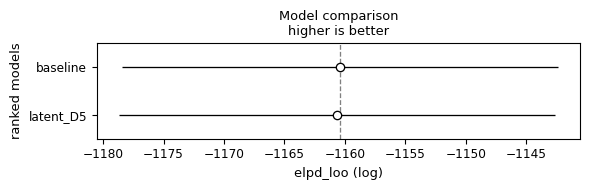

In [ ]:
best_name = comparison.index[0]
best_cfg = prior_configs[best_name]
print(f"Best model: {best_name} (σ_p={best_cfg['sp']}, σ_c={best_cfg['sc']}, σ_b={best_cfg['sb']})")

with pm.Model() as lec_model:
    sigma_player = pm.HalfNormal("sigma_player", sigma=best_cfg["sp"])
    sigma_champ  = pm.HalfNormal("sigma_champ",  sigma=best_cfg["sc"])

    # Non-centered
    phi_raw   = pm.Normal("phi_raw",   mu=0.0, sigma=1.0, shape=N_players)
    alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, shape=N_champs)
    phi   = pm.Deterministic("phi",   phi_raw * sigma_player)
    alpha = pm.Deterministic("alpha", alpha_raw * sigma_champ)

    mu_blue    = pm.Normal("mu_blue", mu=0.0, sigma=best_cfg["sb"])
    sigma_blue = pm.HalfNormal("sigma_blue", sigma=0.2)
    beta_blue_raw = pm.Normal("beta_blue_raw", mu=0.0, sigma=1.0, shape=N_leagues)
    beta_blue = pm.Deterministic("beta_blue", mu_blue + beta_blue_raw * sigma_blue)

    player_adv = phi[blue_players].sum(axis=1) - phi[red_players].sum(axis=1)
    champ_adv  = alpha[blue_champs].sum(axis=1) - alpha[red_champs].sum(axis=1)

    eta = beta_blue[league_ids] + player_adv + champ_adv
    p   = pm.math.sigmoid(eta)
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

with lec_model:
    idata = pm.sample(
        draws=2000, tune=2000,
        target_accept=0.99,
        chains=4,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

divergences = idata.sample_stats["diverging"].sum().values
print(f"Divergences: {divergences}")

### Inspect Learned Parameters

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

az.plot_posterior(idata, var_names=["sigma_player"], ax=axes[0])
axes[0].set_title("Learned σ_player")

az.plot_posterior(idata, var_names=["sigma_champ"], ax=axes[1])
axes[1].set_title("Learned σ_champ")

az.plot_posterior(idata, var_names=["mu_blue"], ax=axes[2])
axes[2].set_title("Learned μ_blue")

plt.tight_layout()
plt.show()

print(az.summary(idata, var_names=[
    "sigma_player", "sigma_champ", "mu_blue", "sigma_blue"
]))

# Blue side advantage per league
beta_blue_mean = idata.posterior["beta_blue"].mean(dim=("chain", "draw")).values
print("\nBlue side advantage per league:")
for _, row in league_lookup.iterrows():
    lid = row["league_id"]
    print(f"  {row['league_name']}: {beta_blue_mean[lid]:.3f}")


--- D=2 ---


Initializing NUTS using advi...


Output()

Interrupted at 49,128 [24%]: Average Loss = 1,307.9
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_player, sigma_champ, phi_raw, alpha_raw, sigma_u, sigma_v, u_raw, v_raw, mu_blue, sigma_blue, beta_blue_raw]


Output()

### Trace plots

In [ ]:
az.plot_trace(idata, var_names=["sigma_player", "sigma_champ", "mu_blue", "sigma_blue"])
plt.tight_layout()
plt.show()

### Posterior Predictive Check

In [ ]:
with lec_model:
    idata_ppc = pm.sample_posterior_predictive(idata, random_seed=42)

y_pred_samples = idata_ppc.posterior_predictive["y_obs"].stack(sample=("chain", "draw"))
pred_prob = y_pred_samples.mean(dim="sample").values

plt.figure(figsize=(10, 5))
plt.scatter(pred_prob, y, alpha=0.3)
plt.xlabel("Predicted probability blue wins")
plt.ylabel("Actual result (0=loss, 1=win)")
plt.title("Posterior Predictive Check")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(pred_prob[y == 1], bins=30, alpha=0.6, label="Actual win")
plt.hist(pred_prob[y == 0], bins=30, alpha=0.6, label="Actual loss")
plt.xlabel("Predicted probability")
plt.ylabel("Number of games")
plt.title("Distribution of Predicted Win Probabilities")
plt.legend()
plt.show()

y_pred_class = (pred_prob > 0.5).astype(int)
accuracy = (y_pred_class == y).mean()
print(f"Posterior predictive accuracy: {accuracy:.3f}")

print("\nAccuracy per league:")
for _, row in league_lookup.iterrows():
    lid = row["league_id"]
    mask = league_ids == lid
    league_acc = (y_pred_class[mask] == y[mask]).mean()
    print(f"  {row['league_name']}: {league_acc:.3f} ({mask.sum()} matches)")


--- Fitting: tight (σ_p=0.1, σ_c=0.1, σ_b=0.3) ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_player, sigma_champ, phi_raw, alpha_raw, mu_blue, sigma_blue, beta_blue_raw]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 118 seconds.


  tight: 0 divergences

--- Fitting: medium (σ_p=0.3, σ_c=0.2, σ_b=0.5) ---


...

  wide: 0 divergences

--- Fitting: data_led (σ_p=0.4, σ_c=0.2, σ_b=0.5) ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_player, sigma_champ, phi_raw, alpha_raw, mu_blue, sigma_blue, beta_blue_raw]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 150 seconds.


  data_led: 0 divergences


### Load Lookups

In [ ]:
player_lookup = pd.read_csv(PROCESSED_DIR / "player_lookup.csv")
champ_lookup  = pd.read_csv(PROCESSED_DIR / "champ_lookup.csv")

print(f"Players: {len(player_lookup)}")
print(f"Champions: {len(champ_lookup)}")

### Extract Posteriors & Build DataFrames

In [ ]:
phi_mean   = idata.posterior["phi"].mean(dim=("chain", "draw")).values
alpha_mean = idata.posterior["alpha"].mean(dim=("chain", "draw")).values

hdi_data       = az.hdi(idata, hdi_prob=0.94)
phi_hdi_vals   = hdi_data["phi"].values
alpha_hdi_vals = hdi_data["alpha"].values

phi_hdi_low    = phi_hdi_vals[:, 0]
phi_hdi_high   = phi_hdi_vals[:, 1]
alpha_hdi_low  = alpha_hdi_vals[:, 0]
alpha_hdi_high = alpha_hdi_vals[:, 1]

players_df = pd.DataFrame({
    "player_id":   np.arange(N_players),
    "mean_effect": phi_mean,
    "hdi_low":     phi_hdi_low,
    "hdi_high":    phi_hdi_high,
    "n_games":     player_game_counts
})

champs_df = pd.DataFrame({
    "champ_id":   np.arange(N_champs),
    "mean_effect": alpha_mean,
    "hdi_low":     alpha_hdi_low,
    "hdi_high":    alpha_hdi_high,
    "n_games":     champ_game_counts
})

players_df = players_df.merge(player_lookup, on="player_id", how="left")
champs_df  = champs_df.merge(champ_lookup,  on="champ_id",  how="left")

players_df = players_df.sort_values("mean_effect", ascending=False)
champs_df  = champs_df.sort_values("mean_effect", ascending=False)

players_df["significant"] = (players_df["hdi_low"] > 0) | (players_df["hdi_high"] < 0)
champs_df["significant"]  = (champs_df["hdi_low"] > 0) | (champs_df["hdi_high"] < 0)

print("Top 10 players by effect:")
print(players_df[["player_name","mean_effect","hdi_low","hdi_high","n_games","significant"]].head(10).to_string(index=False))

print(f"\nPlayers with HDI excluding zero: {players_df['significant'].sum()} / {N_players}")

print("\nTop 10 champions by effect:")
print(champs_df[["champ_name","mean_effect","hdi_low","hdi_high","n_games","significant"]].head(10).to_string(index=False))

print(f"\nChampions with HDI excluding zero: {champs_df['significant'].sum()} / {N_champs}")

### Plot Player Effects

In [ ]:
top_n = 20

# Top players
top_players = players_df.head(top_n)
plt.figure(figsize=(14, 6))
plt.errorbar(
    x=range(top_n),
    y=top_players["mean_effect"],
    yerr=[top_players["mean_effect"] - top_players["hdi_low"],
          top_players["hdi_high"] - top_players["mean_effect"]],
    fmt='o', alpha=0.7
)
plt.xticks(range(top_n), top_players["player_name"], rotation=45, ha="right")
plt.ylabel("Player effect (phi)")
plt.title("Top 20 Player Effects with 94% HDI")
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()

# Bottom players
bottom_players = players_df.tail(top_n)
plt.figure(figsize=(14, 6))
plt.errorbar(
    x=range(top_n),
    y=bottom_players["mean_effect"],
    yerr=[bottom_players["mean_effect"] - bottom_players["hdi_low"],
          bottom_players["hdi_high"] - bottom_players["mean_effect"]],
    fmt='o', alpha=0.7, color='red'
)
plt.xticks(range(top_n), bottom_players["player_name"], rotation=45, ha="right")
plt.ylabel("Player effect (phi)")
plt.title("Bottom 20 Player Effects with 94% HDI")
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()

### Plot champion effects

In [ ]:
# Top champions
top_champs = champs_df.head(top_n)
plt.figure(figsize=(14, 6))
plt.errorbar(
    x=range(top_n),
    y=top_champs["mean_effect"],
    yerr=[top_champs["mean_effect"] - top_champs["hdi_low"],
          top_champs["hdi_high"] - top_champs["mean_effect"]],
    fmt='o', alpha=0.7, color='orange'
)
plt.xticks(range(top_n), top_champs["champ_name"], rotation=45, ha="right")
plt.ylabel("Champion effect (alpha)")
plt.title("Top 20 Champion Effects with 94% HDI")
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()

# Bottom champions
bottom_champs = champs_df.tail(top_n)
plt.figure(figsize=(14, 6))
plt.errorbar(
    x=range(top_n),
    y=bottom_champs["mean_effect"],
    yerr=[bottom_champs["mean_effect"] - bottom_champs["hdi_low"],
          bottom_champs["hdi_high"] - bottom_champs["mean_effect"]],
    fmt='o', alpha=0.7, color='darkred'
)
plt.xticks(range(top_n), bottom_champs["champ_name"], rotation=45, ha="right")
plt.ylabel("Champion effect (alpha)")
plt.title("Bottom 20 Champion Effects with 94% HDI")
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()